In [1]:
# ============================================================
# Household Load Forecasting
# ============================================================
# Objective:
# Build a clean and reproducible household electricity load
# forecasting pipeline using 15-minute smart meter data.
#
# Notebook structure:
# 1. Setup and imports
# 2. Load and prepare raw data
# 3. Exploratory data analysis (EDA)
# 4. Build interval-based household load
# 5. Select one household for forecasting
# 6. Feature engineering
# 7. Single-step baseline forecasting
# 8. Direct multi-step 24-hour forecasting
# 9. Hyperparameter tuning and final evaluation
# 10. Model saving and inference utilities
#
# Notes:
# - Raw meter readings are cumulative and must be converted to
#   interval-level energy values.
# - All train/validation/test splits are chronological.
# - EDA is included in this notebook, but kept separate from
#   the forecasting pipeline sections.
# ============================================================

In [2]:
# ============================================================
# 1. Setup and Imports
# ============================================================

import sys
from pathlib import Path
import importlib
import itertools
import random
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import holidays

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# project path setup
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [3]:
# ============================================================
# 2. Load Raw Dataset
# ============================================================

data_path = Path("data/household_data_15min_singleindex.csv")

df_raw = pd.read_csv(data_path)

print("Raw dataset shape:", df_raw.shape)
display(df_raw.head())

Raw dataset shape: (153810, 71)


,utc_timestamp,cet_cest_timestamp,DE_KN_industrial1_grid_import,DE_KN_industrial1_pv_1,DE_KN_industrial1_pv_2,DE_KN_industrial2_grid_import,DE_KN_industrial2_pv,DE_KN_industrial2_storage_charge,DE_KN_industrial2_storage_decharge,DE_KN_industrial3_area_offices,...,DE_KN_residential5_refrigerator,DE_KN_residential5_washing_machine,DE_KN_residential6_circulation_pump,DE_KN_residential6_dishwasher,DE_KN_residential6_freezer,DE_KN_residential6_grid_export,DE_KN_residential6_grid_import,DE_KN_residential6_pv,DE_KN_residential6_washing_machine,interpolated
0,2014-12-11T17:45:00Z,2014-12-11T18:45:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2014-12-11T18:00:00Z,2014-12-11T19:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2014-12-11T18:15:00Z,2014-12-11T19:15:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2014-12-11T18:30:00Z,2014-12-11T19:30:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2014-12-11T18:45:00Z,2014-12-11T19:45:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# ============================================================
# 3. Prepare Timestamp and Base DataFrame
# ============================================================

timestamp_col = "cet_cest_timestamp" if "cet_cest_timestamp" in df_raw.columns else "utc_timestamp"

df = df_raw.copy()
df[timestamp_col] = pd.to_datetime(df[timestamp_col], utc=True)
df = df.sort_values(timestamp_col).set_index(timestamp_col)

print("Timestamp column:", timestamp_col)
print("Prepared dataset shape:", df.shape)
print("Index dtype:", df.index.dtype)
display(df.head())

Timestamp column: cet_cest_timestamp
Prepared dataset shape: (153810, 70)
Index dtype: datetime64[us, UTC]


,utc_timestamp,DE_KN_industrial1_grid_import,DE_KN_industrial1_pv_1,DE_KN_industrial1_pv_2,DE_KN_industrial2_grid_import,DE_KN_industrial2_pv,DE_KN_industrial2_storage_charge,DE_KN_industrial2_storage_decharge,DE_KN_industrial3_area_offices,DE_KN_industrial3_area_room_1,...,DE_KN_residential5_refrigerator,DE_KN_residential5_washing_machine,DE_KN_residential6_circulation_pump,DE_KN_residential6_dishwasher,DE_KN_residential6_freezer,DE_KN_residential6_grid_export,DE_KN_residential6_grid_import,DE_KN_residential6_pv,DE_KN_residential6_washing_machine,interpolated
cet_cest_timestamp,,,,,,,,,,,,,,,,,,,,,
2014-12-11 17:45:00+00:00,2014-12-11T17:45:00Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 18:00:00+00:00,2014-12-11T18:00:00Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 18:15:00+00:00,2014-12-11T18:15:00Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 18:30:00+00:00,2014-12-11T18:30:00Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 18:45:00+00:00,2014-12-11T18:45:00Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# ============================================================
# 4. Exploratory Data Analysis (EDA)
# ============================================================
# Goal:
# Explore household signal availability, compare energy patterns
# across households, and identify a suitable household for the
# forecasting pipeline.

In [6]:
# ------------------------------------------------------------
# 4.1 Household Signal Overview
# ------------------------------------------------------------

residential_ids = [1, 2, 3, 4, 5, 6]

overview_rows = []

for house_id in residential_ids:
    prefix = f"DE_KN_residential{house_id}_"

    # expected key household energy management signals
    grid_import_col = f"{prefix}grid_import"
    grid_export_col = f"{prefix}grid_export"
    pv_col = f"{prefix}pv"
    ev_col = f"{prefix}ev"
    heat_pump_col = f"{prefix}heat_pump"

    # all columns belonging to this household
    house_cols = [c for c in df.columns if c.startswith(prefix)]

    if len(house_cols) > 0:
        total_cells = df[house_cols].shape[0] * df[house_cols].shape[1]
        missing_cells = df[house_cols].isna().sum().sum()
        missing_percent = 100 * missing_cells / total_cells
        non_null_rows = df[house_cols].dropna(how="all").shape[0]
    else:
        missing_percent = np.nan
        non_null_rows = 0

    overview_rows.append({
        "household": f"residential{house_id}",
        "n_columns": len(house_cols),
        "grid_import": grid_import_col in df.columns,
        "grid_export": grid_export_col in df.columns,
        "pv": pv_col in df.columns,
        "ev": ev_col in df.columns,
        "heat_pump": heat_pump_col in df.columns,
        "non_null_rows": non_null_rows,
        "missing_percent_all_house_cols": round(missing_percent, 2) if not np.isnan(missing_percent) else np.nan,
        "columns": ", ".join(house_cols)
    })

overview_df = pd.DataFrame(overview_rows)

def hems_note(row):
    if row["ev"] and row["pv"] and row["grid_import"] and row["grid_export"]:
        return "very strong HEMS case"
    elif row["pv"] and row["grid_import"] and row["grid_export"]:
        return "strong solar/grid case"
    elif row["pv"] and row["grid_import"]:
        return "baseline solar case"
    elif row["grid_import"]:
        return "limited case"
    else:
        return "weak case"

overview_df["hems_note"] = overview_df.apply(hems_note, axis=1)

display(overview_df[[
    "household",
    "n_columns",
    "grid_import",
    "grid_export",
    "pv",
    "ev",
    "heat_pump",
    "non_null_rows",
    "missing_percent_all_house_cols",
    "hems_note"
]])

,household,n_columns,grid_import,grid_export,pv,ev,heat_pump,non_null_rows,missing_percent_all_house_cols,hems_note
0,residential1,6,True,False,True,False,True,63487,60.04,baseline solar case
1,residential2,5,True,False,False,False,False,99792,53.33,limited case
2,residential3,8,True,True,True,False,False,132840,33.78,strong solar/grid case
3,residential4,9,True,True,True,True,True,81435,56.77,very strong HEMS case
4,residential5,4,True,False,False,False,False,123211,39.90,limited case
5,residential6,7,True,True,True,False,False,86137,53.38,strong solar/grid case


In [7]:
# ------------------------------------------------------------
# 4.2 Build Interval-Based Energy Master Table
# ------------------------------------------------------------

def compute_interval(series):
    """
    Convert cumulative meter readings to interval values.
    Negative diffs are clipped to zero.
    """
    return series.diff().clip(lower=0)


houses = [1, 2, 3, 4, 5, 6]
master_rows = []

for h in houses:
    prefix = f"DE_KN_residential{h}_"

    def get_col(col_name):
        full_col = prefix + col_name
        if full_col in df.columns:
            return compute_interval(df[full_col])
        else:
            return pd.Series(0.0, index=df.index)

    grid_import = get_col("grid_import")
    grid_export = get_col("grid_export")
    pv = get_col("pv")

    washing_machine = get_col("washing_machine")
    dishwasher = get_col("dishwasher")
    refrigerator = get_col("refrigerator")
    freezer = get_col("freezer")
    circulation_pump = get_col("circulation_pump")
    heat_pump = get_col("heat_pump")
    ev = get_col("ev")

    # load definition
    load = (grid_import + pv - grid_export).clip(lower=0)

    temp_df = pd.DataFrame({
        "timestamp": df.index,
        "household": f"residential{h}",
        "grid_import_kwh_15m": grid_import,
        "grid_export_kwh_15m": grid_export,
        "pv_kwh_15m": pv,
        "load_kwh_15m": load,
        "washing_machine_kwh_15m": washing_machine,
        "dishwasher_kwh_15m": dishwasher,
        "refrigerator_kwh_15m": refrigerator,
        "freezer_kwh_15m": freezer,
        "circulation_pump_kwh_15m": circulation_pump,
        "heat_pump_kwh_15m": heat_pump,
        "ev_kwh_15m": ev,
    })

    temp_df = temp_df.dropna(subset=["timestamp"]).copy()
    master_rows.append(temp_df)

energy_master_df = pd.concat(master_rows, ignore_index=True)

print("Energy master table shape:", energy_master_df.shape)
display(energy_master_df.head())

Energy master table shape: (922860, 13)


,timestamp,household,grid_import_kwh_15m,grid_export_kwh_15m,pv_kwh_15m,load_kwh_15m,washing_machine_kwh_15m,dishwasher_kwh_15m,refrigerator_kwh_15m,freezer_kwh_15m,circulation_pump_kwh_15m,heat_pump_kwh_15m,ev_kwh_15m
0,2014-12-11 17:45:00+00:00,residential1,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,0.0
1,2014-12-11 18:00:00+00:00,residential1,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,0.0
2,2014-12-11 18:15:00+00:00,residential1,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,0.0
3,2014-12-11 18:30:00+00:00,residential1,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,0.0
4,2014-12-11 18:45:00+00:00,residential1,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,0.0


In [8]:
# ------------------------------------------------------------
# 4.3 Household Energy Summary (Numerical Comparison)
# ------------------------------------------------------------

summary_rows = []

for household, g in energy_master_df.groupby("household"):

    total_import = g["grid_import_kwh_15m"].sum()
    total_export = g["grid_export_kwh_15m"].sum()
    total_pv = g["pv_kwh_15m"].sum()
    total_load = g["load_kwh_15m"].sum()

    total_washing_machine = g["washing_machine_kwh_15m"].sum()
    total_dishwasher = g["dishwasher_kwh_15m"].sum()
    total_refrigerator = g["refrigerator_kwh_15m"].sum()
    total_freezer = g["freezer_kwh_15m"].sum()
    total_circulation_pump = g["circulation_pump_kwh_15m"].sum()
    total_heat_pump = g["heat_pump_kwh_15m"].sum()
    total_ev = g["ev_kwh_15m"].sum()

    appliance_total = (
        total_washing_machine +
        total_dishwasher +
        total_refrigerator +
        total_freezer +
        total_circulation_pump +
        total_heat_pump +
        total_ev
    )

    appliance_ratio = appliance_total / total_load if total_load > 0 else np.nan
    pv_self_consumption_ratio = (
        (total_pv - total_export) / total_pv if total_pv > 0 else np.nan
    )

    summary_rows.append({
        "household": household,

        "total_load_kwh": round(total_load, 2),
        "total_import_kwh": round(total_import, 2),
        "total_export_kwh": round(total_export, 2),
        "total_pv_kwh": round(total_pv, 2),

        "appliance_total_kwh": round(appliance_total, 2),
        "appliance_to_load_ratio": round(appliance_ratio, 3) if not np.isnan(appliance_ratio) else np.nan,

        "pv_self_consumption_ratio": round(pv_self_consumption_ratio, 3) if not np.isnan(pv_self_consumption_ratio) else np.nan,

        "ev_kwh": round(total_ev, 2),
        "heat_pump_kwh": round(total_heat_pump, 2),
    })

household_summary_df = pd.DataFrame(summary_rows).sort_values("total_load_kwh", ascending=False)

display(household_summary_df)

,household,total_load_kwh,total_import_kwh,total_export_kwh,total_pv_kwh,appliance_total_kwh,appliance_to_load_ratio,pv_self_consumption_ratio,ev_kwh,heat_pump_kwh
0,residential1,25618.16,9096.36,0.00,16521.80,11235.20,0.439,1.000,0.00,10213.52
5,residential6,18198.15,7348.30,3443.15,20495.40,1272.12,0.070,0.832,0.00,0.00
3,residential4,15902.97,10247.07,19070.75,24576.44,7802.16,0.491,0.224,2225.03,4728.82
4,residential5,8773.78,8773.78,0.00,0.00,1695.74,0.193,NaN,0.00,0.00
2,residential3,8378.97,5778.08,9388.80,13673.66,5751.44,0.686,0.313,0.00,0.00
1,residential2,4495.45,4495.45,0.00,0.00,2033.76,0.452,NaN,0.00,0.00


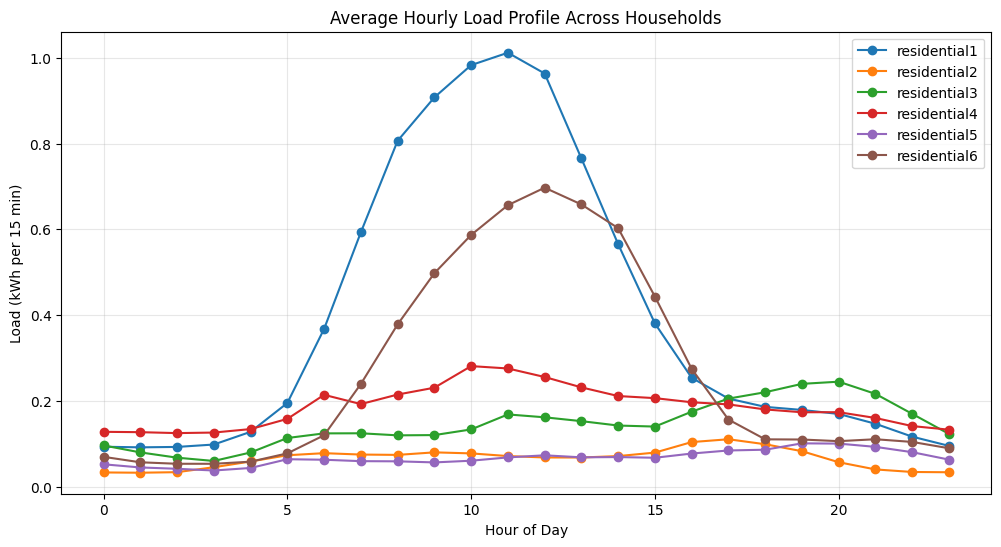

In [9]:
# ------------------------------------------------------------
# 4.4 Average Hourly Load Profile (All Households)
# ------------------------------------------------------------

eda_df = energy_master_df.copy()

# ensure timestamp is datetime
eda_df["timestamp"] = pd.to_datetime(eda_df["timestamp"], utc=True)

# extract hour
eda_df["hour"] = eda_df["timestamp"].dt.hour

# --------------------------------------------
# remove extreme outliers (per household)
# --------------------------------------------
q99 = eda_df.groupby("household")["load_kwh_15m"].quantile(0.99).to_dict()

eda_df["q99"] = eda_df["household"].map(q99)

eda_df_clean = eda_df[eda_df["load_kwh_15m"] <= eda_df["q99"]].copy()

# --------------------------------------------
# compute hourly average
# --------------------------------------------
hourly_profile_df = (
    eda_df_clean
    .groupby(["household", "hour"], as_index=False)["load_kwh_15m"]
    .mean()
)

# --------------------------------------------
# plot
# --------------------------------------------
plt.figure(figsize=(12, 6))

for household in sorted(hourly_profile_df["household"].unique()):
    
    temp = hourly_profile_df[hourly_profile_df["household"] == household]
    
    plt.plot(
        temp["hour"],
        temp["load_kwh_15m"],
        marker="o",
        label=household
    )

plt.title("Average Hourly Load Profile Across Households")
plt.xlabel("Hour of Day")
plt.ylabel("Load (kWh per 15 min)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

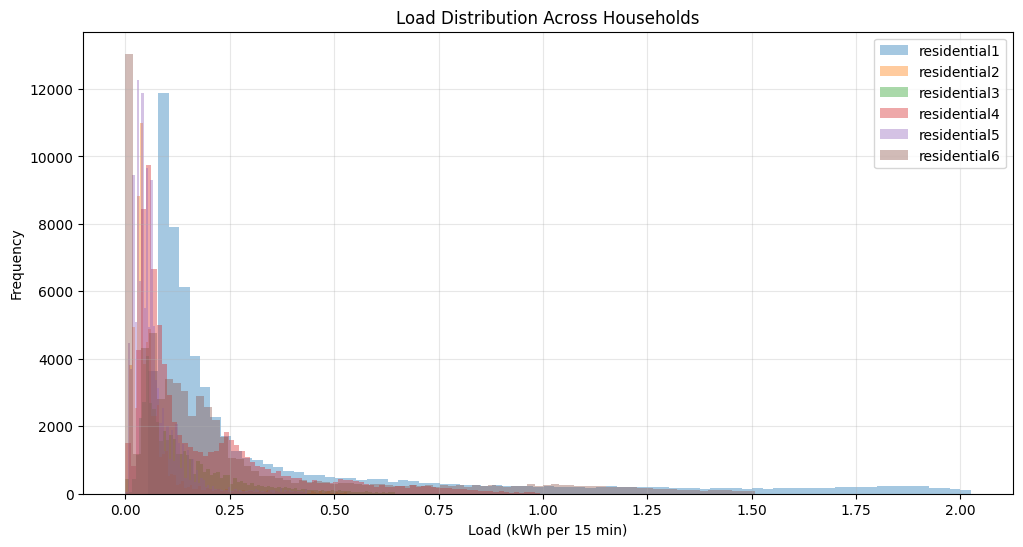

In [10]:
# ------------------------------------------------------------
# 4.5 Load Distribution Across Households
# ------------------------------------------------------------

# reuse cleaned EDA dataframe (with outliers removed)
dist_df = eda_df_clean.copy()

plt.figure(figsize=(12, 6))

for household in sorted(dist_df["household"].unique()):

    subset = dist_df[dist_df["household"] == household]

    plt.hist(
        subset["load_kwh_15m"],
        bins=80,
        alpha=0.4,
        label=household
    )

plt.title("Load Distribution Across Households")
plt.xlabel("Load (kWh per 15 min)")
plt.ylabel("Frequency")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

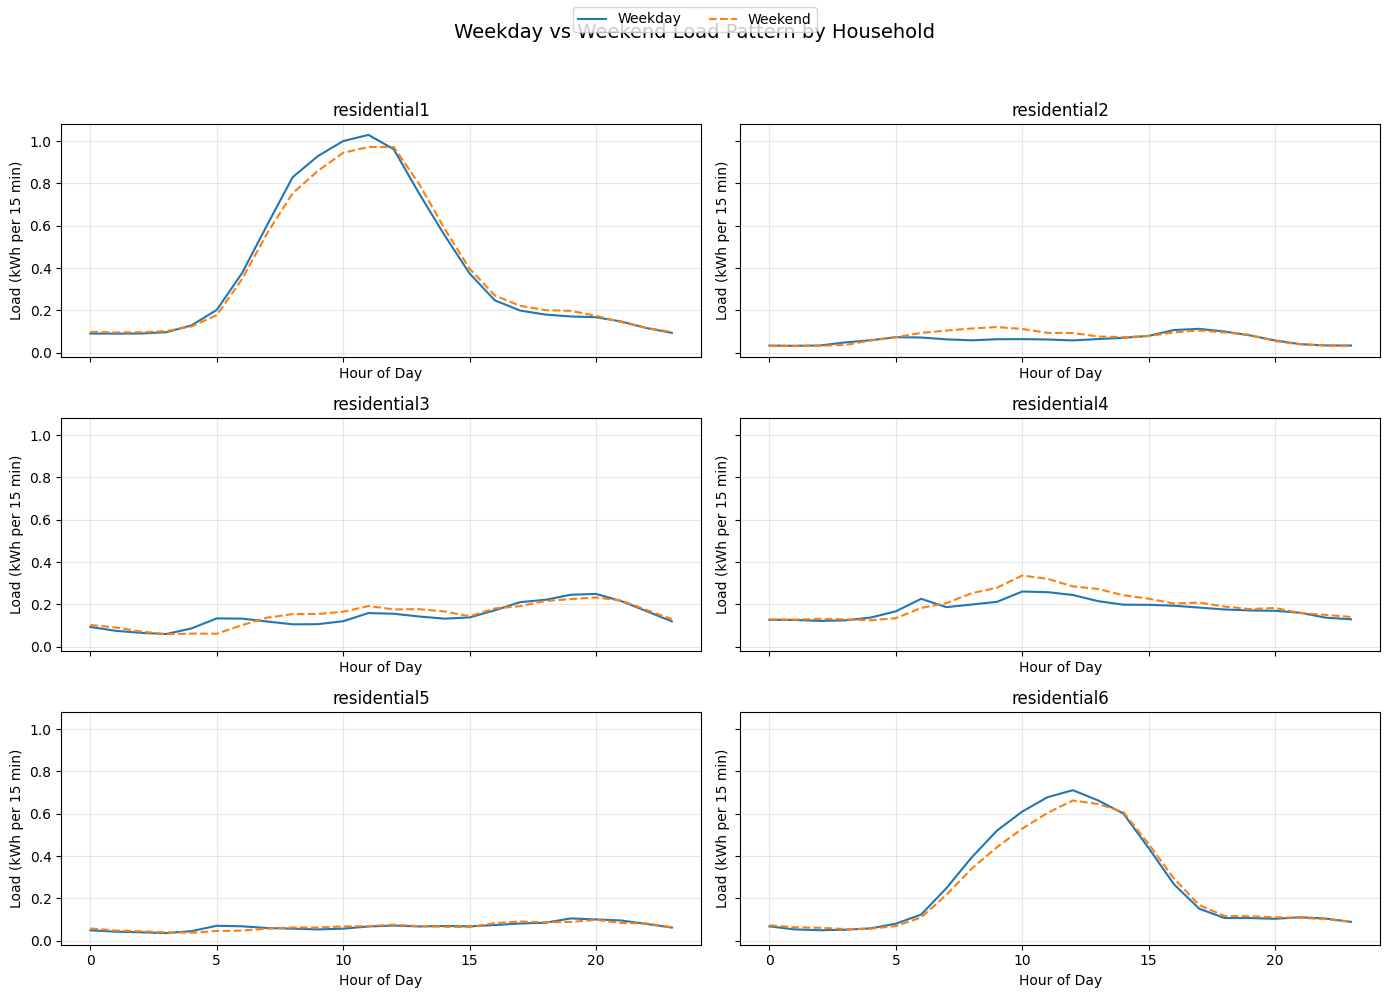

In [11]:
# ------------------------------------------------------------
# 4.6 Weekday vs Weekend Load Pattern (Per Household)
# ------------------------------------------------------------

week_df = energy_master_df.copy()

# ensure timestamp format
week_df["timestamp"] = pd.to_datetime(week_df["timestamp"], utc=True)

# calendar features
week_df["hour"] = week_df["timestamp"].dt.hour
week_df["day_of_week"] = week_df["timestamp"].dt.dayofweek
week_df["is_weekend"] = week_df["day_of_week"] >= 5

# remove extreme outliers per household
q99 = week_df.groupby("household")["load_kwh_15m"].quantile(0.99).to_dict()
week_df["q99"] = week_df["household"].map(q99)

week_df_clean = week_df[week_df["load_kwh_15m"] <= week_df["q99"]].copy()

# build weekday and weekend hourly profiles
weekday_profile = (
    week_df_clean[week_df_clean["is_weekend"] == False]
    .groupby(["household", "hour"], as_index=False)["load_kwh_15m"]
    .mean()
)

weekend_profile = (
    week_df_clean[week_df_clean["is_weekend"] == True]
    .groupby(["household", "hour"], as_index=False)["load_kwh_15m"]
    .mean()
)

households = sorted(week_df_clean["household"].unique())

fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, h in enumerate(households):
    ax = axes[i]

    wday = weekday_profile[weekday_profile["household"] == h]
    wend = weekend_profile[weekend_profile["household"] == h]

    ax.plot(
        wday["hour"],
        wday["load_kwh_15m"],
        label="Weekday"
    )

    ax.plot(
        wend["hour"],
        wend["load_kwh_15m"],
        linestyle="--",
        label="Weekend"
    )

    ax.set_title(h)
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Load (kWh per 15 min)")
    ax.grid(alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)

fig.suptitle("Weekday vs Weekend Load Pattern by Household", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

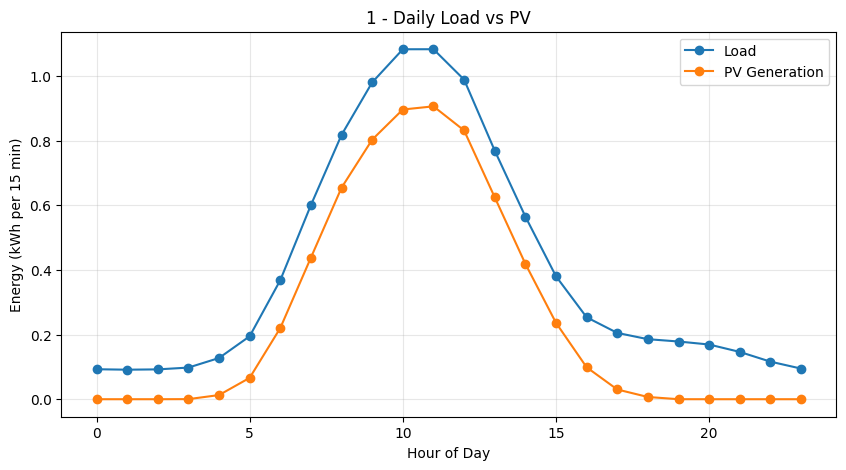

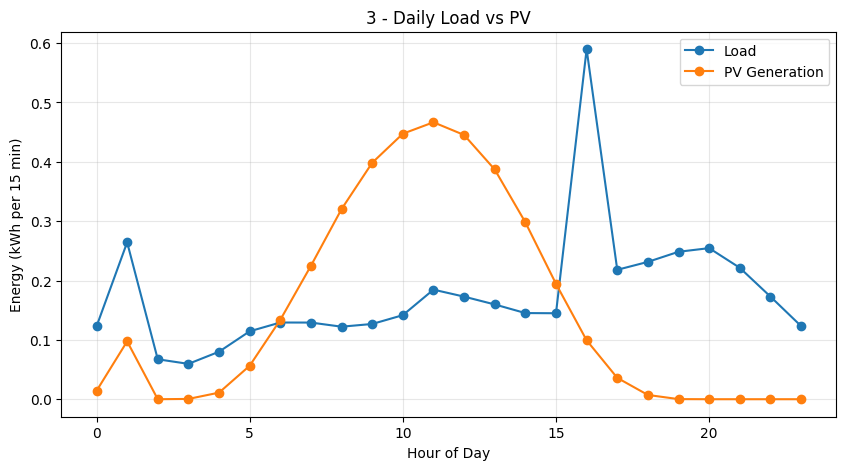

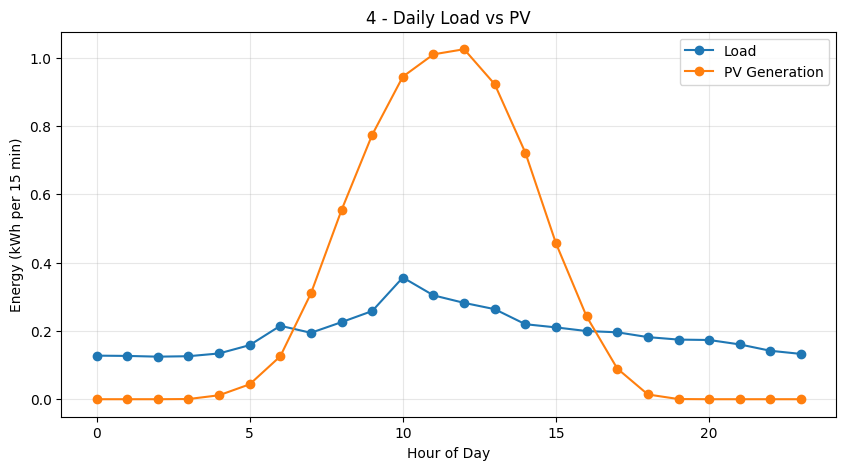

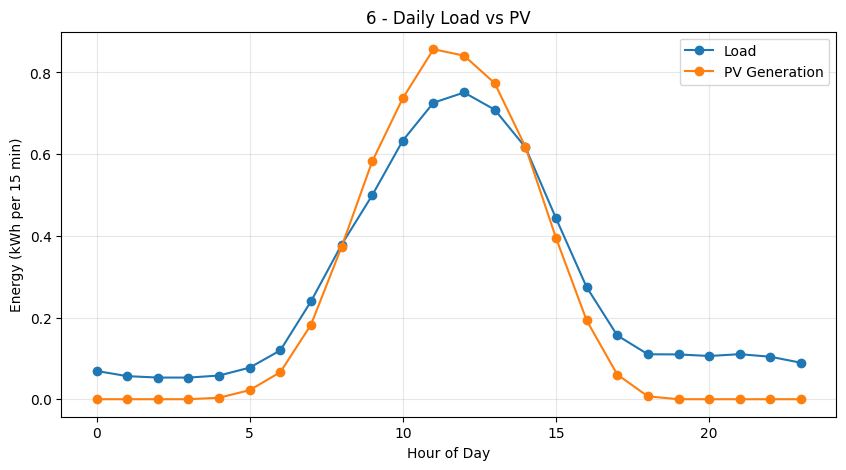

In [12]:
# ------------------------------------------------------------
# 4.7 Daily Load vs PV Generation (PV Households)
# ------------------------------------------------------------

pv_houses = [1, 3, 4, 6]

for h in pv_houses:

    load_col = "load_kwh_15m"
    pv_col = "pv_kwh_15m"

    temp = energy_master_df[
        energy_master_df["household"] == f"residential{h}"
    ].copy()

    temp["timestamp"] = pd.to_datetime(temp["timestamp"], utc=True)
    temp["hour"] = temp["timestamp"].dt.hour

    # aggregate hourly averages
    hourly_profile = (
        temp.groupby("hour")[[load_col, pv_col]]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(10, 5))

    plt.plot(
        hourly_profile["hour"],
        hourly_profile[load_col],
        marker="o",
        label="Load"
    )

    plt.plot(
        hourly_profile["hour"],
        hourly_profile[pv_col],
        marker="o",
        label="PV Generation"
    )

    plt.title(f"{h} - Daily Load vs PV")
    plt.xlabel("Hour of Day")
    plt.ylabel("Energy (kWh per 15 min)")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

In [13]:
# ============================================================
# 5. Select Household for Forecasting
# ============================================================

# selected household based on EDA insights
house_id = 1
selected_household = f"residential{house_id}"

print("Selected household:", selected_household)

Selected household: residential1


In [14]:
# ------------------------------------------------------------
# 6. Build Dataset for Selected Household
# ------------------------------------------------------------

df_house = energy_master_df[
    energy_master_df["household"] == selected_household
].copy()

# ensure timestamp is datetime and set as index
df_house["timestamp"] = pd.to_datetime(df_house["timestamp"], utc=True)
df_house = df_house.set_index("timestamp").sort_index()

# keep only target variable for now
df_house = df_house[["load_kwh_15m"]].rename(columns={"load_kwh_15m": "load"})

print("Household dataset shape:", df_house.shape)
display(df_house.head())

Household dataset shape: (153810, 1)


,load
timestamp,
2014-12-11 17:45:00+00:00,NaN
2014-12-11 18:00:00+00:00,NaN
2014-12-11 18:15:00+00:00,NaN
2014-12-11 18:30:00+00:00,NaN
2014-12-11 18:45:00+00:00,NaN


In [15]:
# ------------------------------------------------------------
# 7. Merge Weather Data
# ------------------------------------------------------------

from utils.weather_utils import build_weather_for_household_calendar

weather_df = build_weather_for_household_calendar(
    household_timestamps=df_house.index,
    config_path="user_config.json",
    save_raw_path="data/weather_raw_hourly.csv",
    save_full_path="data/weather_full_15min.csv",
    include_derived=False,
)

# ensure proper datetime format
weather_df["utc_timestamp"] = pd.to_datetime(weather_df["utc_timestamp"], utc=True)
weather_df = weather_df.set_index("utc_timestamp").sort_index()

# drop non-feature columns if present
if "source" in weather_df.columns:
    weather_df = weather_df.drop(columns=["source"])

# merge with household load
df_house = df_house.join(weather_df, how="inner")

print("Shape after weather merge:", df_house.shape)
display(df_house.head())

Shape after weather merge: (153810, 26)


,load,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,weather_code,...,shortwave_radiation,direct_radiation,diffuse_radiation,global_tilted_irradiance,sunshine_duration,wind_speed_10m,wind_direction_10m,wind_gusts_10m,et0_fao_evapotranspiration,vapour_pressure_deficit
timestamp,,,,,,,,,,,,,,,,,,,,,
2014-12-11 17:45:00+00:00,NaN,4.875,79.5,1.650,-0.625,0.30,0.30,0.0,0.0,51.0,...,0.0,0.0,0.0,0.0,0.0,25.125,237.50,55.925,0.0225,0.1775
2014-12-11 18:00:00+00:00,NaN,4.800,80.0,1.700,-0.700,0.30,0.30,0.0,0.0,51.0,...,0.0,0.0,0.0,0.0,0.0,25.100,238.00,58.000,0.0200,0.1700
2014-12-11 18:15:00+00:00,NaN,4.825,80.0,1.725,-0.600,0.35,0.35,0.0,0.0,51.5,...,0.0,0.0,0.0,0.0,0.0,24.675,238.25,58.450,0.0200,0.1700
2014-12-11 18:30:00+00:00,NaN,4.850,80.0,1.750,-0.500,0.40,0.40,0.0,0.0,52.0,...,0.0,0.0,0.0,0.0,0.0,24.250,238.50,58.900,0.0200,0.1700
2014-12-11 18:45:00+00:00,NaN,4.875,80.0,1.775,-0.400,0.45,0.45,0.0,0.0,52.5,...,0.0,0.0,0.0,0.0,0.0,23.825,238.75,59.350,0.0200,0.1700


In [16]:
# ------------------------------------------------------------
# 8. Create Calendar Features
# ------------------------------------------------------------

de_holidays = holidays.Germany()

df_house["hour"] = df_house.index.hour
df_house["day_of_week"] = df_house.index.dayofweek
df_house["month"] = df_house.index.month
df_house["is_weekend"] = (df_house["day_of_week"] >= 5).astype(int)

df_house["is_holiday"] = (
    df_house.index.tz_localize(None).normalize().map(lambda d: int(d in de_holidays))
)

print("Shape after calendar features:", df_house.shape)
display(df_house[[
    "load",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "is_holiday"
]].head())

Shape after calendar features: (153810, 31)


,load,hour,day_of_week,month,is_weekend,is_holiday
timestamp,,,,,,
2014-12-11 17:45:00+00:00,NaN,17,3,12,0,0
2014-12-11 18:00:00+00:00,NaN,18,3,12,0,0
2014-12-11 18:15:00+00:00,NaN,18,3,12,0,0
2014-12-11 18:30:00+00:00,NaN,18,3,12,0,0
2014-12-11 18:45:00+00:00,NaN,18,3,12,0,0


In [17]:
# ------------------------------------------------------------
# 9. Create Lag Features
# ------------------------------------------------------------

df_house["lag_1"] = df_house["load"].shift(1)
df_house["lag_2"] = df_house["load"].shift(2)
df_house["lag_3"] = df_house["load"].shift(3)
df_house["lag_96"] = df_house["load"].shift(96)
df_house["lag_192"] = df_house["load"].shift(192)

print("Shape after lag features:", df_house.shape)
display(df_house[["load", "lag_1", "lag_2", "lag_3", "lag_96", "lag_192"]].head(10))

Shape after lag features: (153810, 36)


,load,lag_1,lag_2,lag_3,lag_96,lag_192
timestamp,,,,,,
2014-12-11 17:45:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 18:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 18:15:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 18:30:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 18:45:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 19:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 19:15:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 19:30:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 19:45:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
# ------------------------------------------------------------
# 10. Create Rolling Features
# ------------------------------------------------------------

df_house["rolling_mean_1h"] = df_house["load"].rolling(window=4).mean()
df_house["rolling_mean_24h"] = df_house["load"].rolling(window=96).mean()

print("Shape after rolling features:", df_house.shape)
display(df_house[[
    "load",
    "rolling_mean_1h",
    "rolling_mean_24h"
]].head(10))

Shape after rolling features: (153810, 38)


,load,rolling_mean_1h,rolling_mean_24h
timestamp,,,
2014-12-11 17:45:00+00:00,NaN,NaN,NaN
2014-12-11 18:00:00+00:00,NaN,NaN,NaN
2014-12-11 18:15:00+00:00,NaN,NaN,NaN
2014-12-11 18:30:00+00:00,NaN,NaN,NaN
2014-12-11 18:45:00+00:00,NaN,NaN,NaN
2014-12-11 19:00:00+00:00,NaN,NaN,NaN
2014-12-11 19:15:00+00:00,NaN,NaN,NaN
2014-12-11 19:30:00+00:00,NaN,NaN,NaN
2014-12-11 19:45:00+00:00,NaN,NaN,NaN


In [19]:
# ------------------------------------------------------------
# 11. Create 24-Hour Ahead Single-Step Target
# ------------------------------------------------------------

forecast_horizon = 96  # 96 x 15 minutes = 24 hours

df_house["target"] = df_house["load"].shift(-forecast_horizon)

print("Shape after target creation:", df_house.shape)
display(df_house[["load", "target"]].head(10))

Shape after target creation: (153810, 39)


,load,target
timestamp,,
2014-12-11 17:45:00+00:00,NaN,NaN
2014-12-11 18:00:00+00:00,NaN,NaN
2014-12-11 18:15:00+00:00,NaN,NaN
2014-12-11 18:30:00+00:00,NaN,NaN
2014-12-11 18:45:00+00:00,NaN,NaN
2014-12-11 19:00:00+00:00,NaN,NaN
2014-12-11 19:15:00+00:00,NaN,NaN
2014-12-11 19:30:00+00:00,NaN,NaN
2014-12-11 19:45:00+00:00,NaN,NaN


In [20]:
# ------------------------------------------------------------
# 12. Drop Rows with Missing Engineered Values
# ------------------------------------------------------------

df_house = df_house.dropna().copy()

print("Final feature-engineered dataset shape:", df_house.shape)
display(df_house.head())

Final feature-engineered dataset shape: (63198, 39)


,load,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,weather_code,...,is_weekend,is_holiday,lag_1,lag_2,lag_3,lag_96,lag_192,rolling_mean_1h,rolling_mean_24h,target
timestamp,,,,,,,,,,,,,,,,,,,,,
2015-05-23 15:45:00+00:00,0.456,14.00,60.75,6.55,11.825,0.0,0.0,0.0,0.0,3.0,...,1,0,0.642,0.374,0.354,0.584,0.157,0.45650,0.482552,0.426
2015-05-23 16:00:00+00:00,0.431,14.00,61.00,6.60,11.900,0.0,0.0,0.0,0.0,3.0,...,1,0,0.456,0.642,0.374,0.529,0.273,0.47575,0.481531,0.451
2015-05-23 16:15:00+00:00,0.431,13.95,61.50,6.65,11.950,0.0,0.0,0.0,0.0,3.0,...,1,0,0.431,0.456,0.642,0.313,0.311,0.49000,0.482760,0.440
2015-05-23 16:30:00+00:00,0.381,13.90,62.00,6.70,12.000,0.0,0.0,0.0,0.0,3.0,...,1,0,0.431,0.431,0.456,0.403,0.280,0.42475,0.482531,0.366
2015-05-23 16:45:00+00:00,0.227,13.85,62.50,6.75,12.050,0.0,0.0,0.0,0.0,3.0,...,1,0,0.381,0.431,0.431,0.200,0.265,0.36750,0.482813,0.312


,lag_steps,lag_hours,pearson_corr,spearman_corr,abs_pearson,abs_spearman
0,1,0.25,0.752661,0.811813,0.752661,0.811813
1,2,0.50,0.744629,0.800267,0.744629,0.800267
2,3,0.75,0.731783,0.783886,0.731783,0.783886
3,96,24.00,0.730439,0.802619,0.730439,0.802619
4,192,48.00,0.717813,0.798456,0.717813,0.798456
5,4,1.00,0.714127,0.762849,0.714127,0.762849
6,5,1.25,0.692237,0.739698,0.692237,0.739698
7,6,1.50,0.666559,0.711732,0.666559,0.711732
8,7,1.75,0.637840,0.681862,0.637840,0.681862
9,8,2.00,0.606205,0.647996,0.606205,0.647996


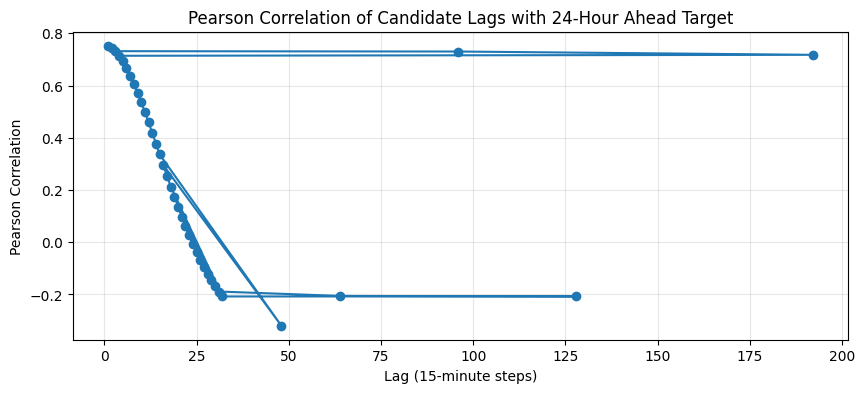

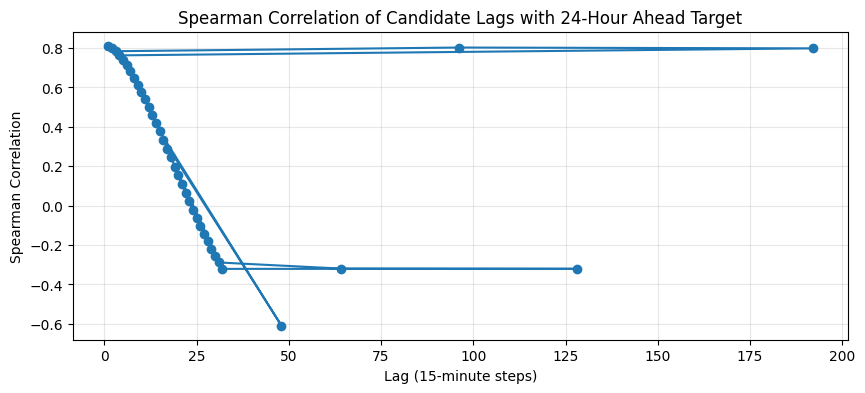

In [21]:
# ------------------------------------------------------------
# 13. Lag Candidate Analysis
# ------------------------------------------------------------

candidate_lags = list(range(1, 33)) + [48, 64, 96, 128, 192]

lag_results = []

for lag in candidate_lags:
    col_name = f"lag_candidate_{lag}"

    temp = df_house[["load", "target"]].copy()
    temp[col_name] = temp["load"].shift(lag)
    temp = temp.dropna()

    pearson_corr = temp[col_name].corr(temp["target"], method="pearson")
    spearman_corr = temp[col_name].corr(temp["target"], method="spearman")

    lag_results.append({
        "lag_steps": lag,
        "lag_hours": lag * 15 / 60,
        "pearson_corr": pearson_corr,
        "spearman_corr": spearman_corr,
        "abs_pearson": abs(pearson_corr),
        "abs_spearman": abs(spearman_corr),
    })

lag_results_df = (
    pd.DataFrame(lag_results)
    .sort_values("abs_pearson", ascending=False)
    .reset_index(drop=True)
)

display(lag_results_df)

plt.figure(figsize=(10, 4))
plt.plot(lag_results_df["lag_steps"], lag_results_df["pearson_corr"], marker="o")
plt.title("Pearson Correlation of Candidate Lags with 24-Hour Ahead Target")
plt.xlabel("Lag (15-minute steps)")
plt.ylabel("Pearson Correlation")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(lag_results_df["lag_steps"], lag_results_df["spearman_corr"], marker="o")
plt.title("Spearman Correlation of Candidate Lags with 24-Hour Ahead Target")
plt.xlabel("Lag (15-minute steps)")
plt.ylabel("Spearman Correlation")
plt.grid(alpha=0.3)
plt.show()

In [22]:
# ------------------------------------------------------------
# 14. Define Fixed and Weather Feature Groups
# ------------------------------------------------------------

fixed_feature_cols = [
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "is_holiday",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_96",
    "lag_192",
    "rolling_mean_1h",
    "rolling_mean_24h",
]

weather_feature_cols = [
    "temperature_2m",
    "relative_humidity_2m",
    "dew_point_2m",
    "apparent_temperature",
    "precipitation",
    "rain",
    "snowfall",
    "snow_depth",
    "weather_code",
    "pressure_msl",
    "surface_pressure",
    "cloud_cover",
    "cloud_cover_low",
    "cloud_cover_mid",
    "cloud_cover_high",
    "shortwave_radiation",
    "direct_radiation",
    "diffuse_radiation",
    "global_tilted_irradiance",
    "sunshine_duration",
    "wind_speed_10m",
    "wind_direction_10m",
    "wind_gusts_10m",
    "et0_fao_evapotranspiration",
    "vapour_pressure_deficit",
]

missing_fixed = [col for col in fixed_feature_cols if col not in df_house.columns]
missing_weather = [col for col in weather_feature_cols if col not in df_house.columns]

print("Missing fixed features:", missing_fixed)
print("Missing weather features:", missing_weather)

assert not missing_fixed, f"Missing fixed features: {missing_fixed}"
assert not missing_weather, f"Missing weather features: {missing_weather}"

Missing fixed features: []
Missing weather features: []


In [23]:
# ------------------------------------------------------------
# 15. Rank Weather Features Using Training Data Only
# ------------------------------------------------------------

split_idx = int(len(df_house) * 0.70)

train_df_fs = df_house.iloc[:split_idx].copy()
val_df_fs = df_house.iloc[split_idx:].copy()

X_train_fs = train_df_fs[fixed_feature_cols + weather_feature_cols]
y_train_fs = train_df_fs["target"]

weather_selector_model = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
)

weather_selector_model.fit(X_train_fs, y_train_fs)

importance_df = pd.DataFrame({
    "feature": X_train_fs.columns,
    "importance": weather_selector_model.feature_importances_,
})

weather_importance_df = (
    importance_df[importance_df["feature"].isin(weather_feature_cols)]
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(weather_importance_df)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004518 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7232
[LightGBM] [Info] Number of data points in the train set: 44238, number of used features: 37
[LightGBM] [Info] Start training from score 0.444154


c:\Users\Mehdi Zamani\.pyenv\pyenv-win\versions\3.11.3\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Mehdi Zamani\.pyenv\pyenv-win\versions\3.11.3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Mehdi Zamani\.pyenv\pyenv-win\versions\3.11.3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Mehdi Zamani\.pyenv\pyenv-win\versions\3.11.3\Lib\subprocess.py", l

,feature,importance
0,surface_pressure,384
1,dew_point_2m,370
2,pressure_msl,332
3,diffuse_radiation,302
4,wind_gusts_10m,268
5,cloud_cover_mid,260
6,wind_direction_10m,250
7,wind_speed_10m,210
8,cloud_cover_high,170
9,apparent_temperature,161


In [24]:
# ------------------------------------------------------------
# 16. Build and Compare Feature Sets
# ------------------------------------------------------------

TOP_K_WEATHER = 8

selected_weather_feature_cols = weather_importance_df.head(TOP_K_WEATHER)["feature"].tolist()

print("Selected weather features:")
print(selected_weather_feature_cols)

feature_cols_no_weather = fixed_feature_cols.copy()
feature_cols_full_weather = fixed_feature_cols + weather_feature_cols
feature_cols_selected_weather = fixed_feature_cols + selected_weather_feature_cols

X_no_weather = df_house[feature_cols_no_weather]
X_full_weather = df_house[feature_cols_full_weather]
X_selected_weather = df_house[feature_cols_selected_weather]

y_all = df_house["target"]

print("No weather shape:", X_no_weather.shape)
print("Full weather shape:", X_full_weather.shape)
print("Selected weather shape:", X_selected_weather.shape)

Selected weather features:
['surface_pressure', 'dew_point_2m', 'pressure_msl', 'diffuse_radiation', 'wind_gusts_10m', 'cloud_cover_mid', 'wind_direction_10m', 'wind_speed_10m']
No weather shape: (63198, 12)
Full weather shape: (63198, 37)
Selected weather shape: (63198, 20)


In [25]:
# ------------------------------------------------------------
# 17. Compare Feature Sets Using LightGBM
# ------------------------------------------------------------

def evaluate_feature_set(X_data, y_data):
    n = len(X_data)

    train_end = int(n * 0.70)
    val_end = int(n * 0.85)

    X_train_local = X_data.iloc[:train_end]
    y_train_local = y_data.iloc[:train_end]

    X_val_local = X_data.iloc[train_end:val_end]
    y_val_local = y_data.iloc[train_end:val_end]

    model = LGBMRegressor(
        n_estimators=100,
        random_state=42,
    )

    model.fit(X_train_local, y_train_local)
    y_pred_local = model.predict(X_val_local)

    mae_local = mean_absolute_error(y_val_local, y_pred_local)
    rmse_local = np.sqrt(mean_squared_error(y_val_local, y_pred_local))

    return {
        "n_features": X_data.shape[1],
        "MAE": mae_local,
        "RMSE": rmse_local,
    }


comparison_rows = []

row_no_weather = evaluate_feature_set(X_no_weather, y_all)
row_no_weather["feature_set"] = "no_weather"

row_full_weather = evaluate_feature_set(X_full_weather, y_all)
row_full_weather["feature_set"] = "full_weather"

row_selected_weather = evaluate_feature_set(X_selected_weather, y_all)
row_selected_weather["feature_set"] = "selected_weather"

comparison_rows.extend([
    row_no_weather,
    row_full_weather,
    row_selected_weather,
])

feature_set_comparison_df = (
    pd.DataFrame(comparison_rows)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(feature_set_comparison_df)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001285 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1833
[LightGBM] [Info] Number of data points in the train set: 44238, number of used features: 12
[LightGBM] [Info] Start training from score 0.444154
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004215 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7232
[LightGBM] [Info] Number of data points in the train set: 44238, number of used features: 37
[LightGBM] [Info] Start training from score 0.444154
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002215 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3862
[LightGBM] [Info] Number of data points in the train set: 44238, number of used features: 20
[LightGBM] [Info] Start tra

,n_features,MAE,RMSE,feature_set
0,37,0.132310,0.239559,full_weather
1,20,0.134594,0.243815,selected_weather
2,12,0.139523,0.252295,no_weather


In [26]:
# ------------------------------------------------------------
# 18. Select Final Feature Set
# ------------------------------------------------------------

# OPTION 1
# X = X_no_weather.copy()

#OPTION 2
X = X_full_weather.copy()

# OPTION 3
# X = X_selected_weather.copy()

y = y_all.copy()

print("Final X shape:", X.shape)
print("Final y shape:", y.shape)
print("Final feature columns:")
print(X.columns.tolist())

Final X shape: (63198, 37)
Final y shape: (63198,)
Final feature columns:
['hour', 'day_of_week', 'month', 'is_weekend', 'is_holiday', 'lag_1', 'lag_2', 'lag_3', 'lag_96', 'lag_192', 'rolling_mean_1h', 'rolling_mean_24h', 'temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'apparent_temperature', 'precipitation', 'rain', 'snowfall', 'snow_depth', 'weather_code', 'pressure_msl', 'surface_pressure', 'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high', 'shortwave_radiation', 'direct_radiation', 'diffuse_radiation', 'global_tilted_irradiance', 'sunshine_duration', 'wind_speed_10m', 'wind_direction_10m', 'wind_gusts_10m', 'et0_fao_evapotranspiration', 'vapour_pressure_deficit']


In [27]:
# --------------------------------------------------
# 19. Chronological Train / Validation / Test Split
# --------------------------------------------------

n = len(X)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (44238, 37) (44238,)
Validation: (9480, 37) (9480,)
Test: (9480, 37) (9480,)


In [28]:
# ------------------------------------------------------------
# 20. Define Single-Step Baseline Models
# ------------------------------------------------------------

models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=100,
        random_state=42
    ),
}

In [29]:
# ------------------------------------------------------------
# 21. Train and Evaluate Single-Step Baseline Models
# ------------------------------------------------------------

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))

    results.append({
        "model": name,
        "MAE": mae,
        "RMSE": rmse,
    })

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)

display(results_df)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004908 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7232
[LightGBM] [Info] Number of data points in the train set: 44238, number of used features: 37
[LightGBM] [Info] Start training from score 0.444154


,model,MAE,RMSE
0,LightGBM,0.132310,0.239559
1,RandomForest,0.134657,0.242049
2,Ridge,0.148230,0.244854
3,LinearRegression,0.148370,0.244915
4,XGBoost,0.142297,0.259711
5,DecisionTree,0.192147,0.367826


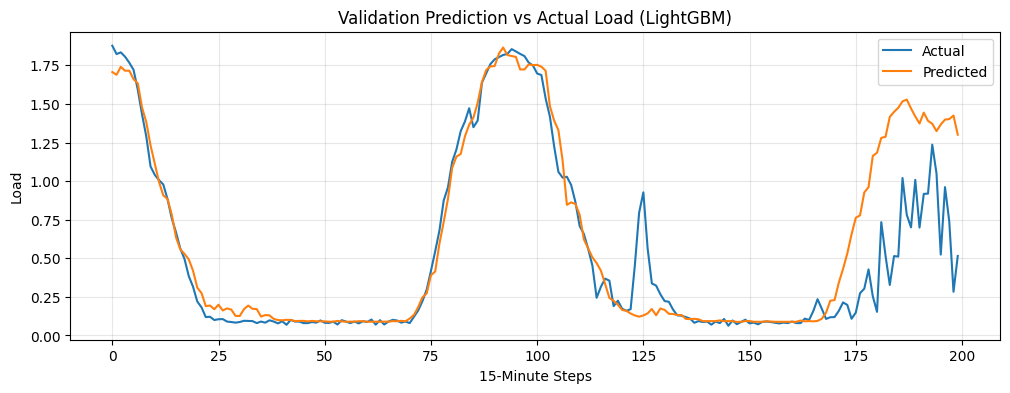

In [30]:
# ------------------------------------------------------------
# 22. Visual Comparison for Best Single-Step Model
# ------------------------------------------------------------

best_model_name = results_df.iloc[0]["model"]
best_model = models[best_model_name]

y_val_pred = best_model.predict(X_val)

plt.figure(figsize=(12, 4))
plt.plot(y_val.values[:200], label="Actual")
plt.plot(y_val_pred[:200], label="Predicted")
plt.title(f"Validation Prediction vs Actual Load ({best_model_name})")
plt.xlabel("15-Minute Steps")
plt.ylabel("Load")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [31]:
# -------------------------------------------------------
# 23. Build Multi-Step Targets (Next 24 Hours)
# -------------------------------------------------------

horizon = 96  # 24 hours ahead (15-min resolution)

y_multi = pd.DataFrame(index=df_house.index)

for h in range(1, horizon + 1):
    y_multi[f"target_t+{h}"] = df_house["load"].shift(-h)

display(y_multi.head())

,target_t+1,target_t+2,target_t+3,target_t+4,target_t+5,target_t+6,target_t+7,target_t+8,target_t+9,target_t+10,...,target_t+87,target_t+88,target_t+89,target_t+90,target_t+91,target_t+92,target_t+93,target_t+94,target_t+95,target_t+96
timestamp,,,,,,,,,,,,,,,,,,,,,
2015-05-23 15:45:00+00:00,0.431,0.431,0.381,0.227,0.241,0.267,0.242,0.204,0.146,0.133,...,0.838,0.891,0.921,0.780,0.711,0.677,0.644,0.575,0.488,0.426
2015-05-23 16:00:00+00:00,0.431,0.381,0.227,0.241,0.267,0.242,0.204,0.146,0.133,0.144,...,0.891,0.921,0.780,0.711,0.677,0.644,0.575,0.488,0.426,0.451
2015-05-23 16:15:00+00:00,0.381,0.227,0.241,0.267,0.242,0.204,0.146,0.133,0.144,0.263,...,0.921,0.780,0.711,0.677,0.644,0.575,0.488,0.426,0.451,0.440
2015-05-23 16:30:00+00:00,0.227,0.241,0.267,0.242,0.204,0.146,0.133,0.144,0.263,0.130,...,0.780,0.711,0.677,0.644,0.575,0.488,0.426,0.451,0.440,0.366
2015-05-23 16:45:00+00:00,0.241,0.267,0.242,0.204,0.146,0.133,0.144,0.263,0.130,0.157,...,0.711,0.677,0.644,0.575,0.488,0.426,0.451,0.440,0.366,0.312


In [32]:
# --------------------------------------------------------
# 24. Align Features and Multi-Step Targets
# --------------------------------------------------------

data_multi = pd.concat([X, y_multi], axis=1).dropna()

print("Aligned multi-step dataset shape:", data_multi.shape)

Aligned multi-step dataset shape: (63102, 133)


In [33]:
# ---------------------------------------------------
# 25. Separate Multi-Step Inputs and Targets
# ---------------------------------------------------

X_multi = data_multi[X.columns]
y_multi = data_multi[y_multi.columns]

print("X_multi shape:", X_multi.shape)
print("y_multi shape:", y_multi.shape)

X_multi shape: (63102, 37)
y_multi shape: (63102, 96)


In [34]:
# ---------------------------------------------------------
# 26. Chronological Split for Multi-Step Forecasting
# ---------------------------------------------------------

n = len(X_multi)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X_multi.iloc[:train_end]
y_train = y_multi.iloc[:train_end]

X_val = X_multi.iloc[train_end:val_end]
y_val = y_multi.iloc[train_end:val_end]

X_test = X_multi.iloc[val_end:]
y_test = y_multi.iloc[val_end:]

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (44171, 37) (44171, 96)
Validation: (9465, 37) (9465, 96)
Test: (9466, 37) (9466, 96)


In [35]:
# ---------------------------------------------------------
# 27. Train Multi-Output LightGBM Model
# ---------------------------------------------------------

multi_lgbm = MultiOutputRegressor(
    LGBMRegressor(
        n_estimators=100,
        random_state=42
    )
)

multi_lgbm.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003376 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7233
[LightGBM] [Info] Number of data points in the train set: 44171, number of used features: 37
[LightGBM] [Info] Start training from score 0.443630
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004737 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7233
[LightGBM] [Info] Number of data points in the train set: 44171, number of used features: 37
[LightGBM] [Info] Start training from score 0.443624
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004481 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7233
[LightGBM] [Info] Number of data points in the train set: 44171, number of used features: 37
[LightGBM] [Info] Start tra

MultiOutputRegressor(estimator=LGBMRegressor(random_state=42))

In [36]:
# ---------------------------------------------------------
# 28. Generate Validation Forecasts
# ---------------------------------------------------------

y_val_pred = multi_lgbm.predict(X_val)

print("Validation prediction shape:", y_val_pred.shape)

Validation prediction shape: (9465, 96)


In [37]:
# ---------------------------------------------------------
# 29. Evaluate Multi-Step Performance
# ---------------------------------------------------------

mae = mean_absolute_error(y_val.values.flatten(), y_val_pred.flatten())
rmse = np.sqrt(mean_squared_error(y_val.values.flatten(), y_val_pred.flatten()))

print("Validation MAE:", mae)
print("Validation RMSE:", rmse)

Validation MAE: 0.13282816633249842
Validation RMSE: 0.23827533445172938


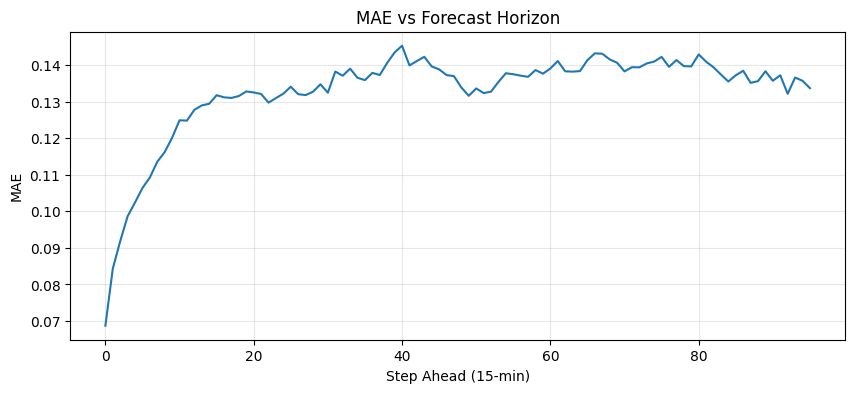

In [38]:
# ---------------------------------------------------------
# 30. MAE per Forecast Horizon
# ---------------------------------------------------------

mae_per_step = []

for h in range(horizon):
    mae_h = mean_absolute_error(y_val.iloc[:, h], y_val_pred[:, h])
    mae_per_step.append(mae_h)

plt.figure(figsize=(10, 4))
plt.plot(mae_per_step)
plt.title("MAE vs Forecast Horizon")
plt.xlabel("Step Ahead (15-min)")
plt.ylabel("MAE")
plt.grid(alpha=0.3)
plt.show()

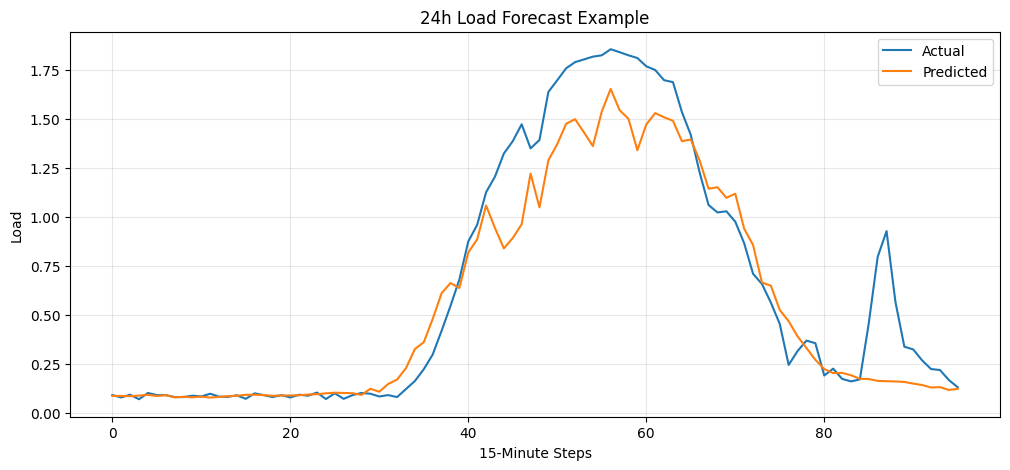

In [39]:
# ---------------------------------------------------------
# 31. Example 24h Forecast
# ---------------------------------------------------------

sample = 200

plt.figure(figsize=(12, 5))
plt.plot(y_val.iloc[sample].values, label="Actual")
plt.plot(y_val_pred[sample], label="Predicted")

plt.title("24h Load Forecast Example")
plt.xlabel("15-Minute Steps")
plt.ylabel("Load")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [40]:
# ---------------------------------------------------------
# 32. Define Hyperparameter Search Space
# ---------------------------------------------------------

param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "num_leaves": [15, 31, 63, 127],
    "max_depth": [-1, 5, 10, 15],
    "min_child_samples": [10, 20, 30, 50],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "reg_alpha": [0.0, 0.1, 0.5],
    "reg_lambda": [0.0, 0.1, 0.5, 1.0],
}

In [41]:
# ---------------------------------------------------------
# 33. Randomized Hyperparameter Tuning
# ---------------------------------------------------------

random.seed(42)

all_param_combinations = list(itertools.product(
    param_grid["n_estimators"],
    param_grid["learning_rate"],
    param_grid["num_leaves"],
    param_grid["max_depth"],
    param_grid["min_child_samples"],
    param_grid["subsample"],
    param_grid["colsample_bytree"],
    param_grid["reg_alpha"],
    param_grid["reg_lambda"],
))

print("Total possible combinations:", len(all_param_combinations))

n_trials = 20
sampled_combinations = random.sample(
    all_param_combinations,
    min(n_trials, len(all_param_combinations))
)

tuning_results = []

for i, combo in enumerate(sampled_combinations, start=1):
    params = {
        "n_estimators": combo[0],
        "learning_rate": combo[1],
        "num_leaves": combo[2],
        "max_depth": combo[3],
        "min_child_samples": combo[4],
        "subsample": combo[5],
        "colsample_bytree": combo[6],
        "reg_alpha": combo[7],
        "reg_lambda": combo[8],
    }

    print(f"Running config {i}/{len(sampled_combinations)}")
    print(params)

    model = MultiOutputRegressor(
        LGBMRegressor(
            random_state=42,
            verbosity=-1,
            **params
        )
    )

    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)

    mae = mean_absolute_error(y_val.values.flatten(), y_val_pred.flatten())
    rmse = np.sqrt(mean_squared_error(y_val.values.flatten(), y_val_pred.flatten()))

    row = params.copy()
    row["MAE"] = mae
    row["RMSE"] = rmse
    tuning_results.append(row)

tuning_results_df = (
    pd.DataFrame(tuning_results)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(tuning_results_df.head(10))

Total possible combinations: 196608
Running config 1/20
{'n_estimators': 500, 'learning_rate': 0.03, 'num_leaves': 63, 'max_depth': 10, 'min_child_samples': 20, 'subsample': 0.7, 'colsample_bytree': 0.7, 'reg_alpha': 0.1, 'reg_lambda': 0.1}
Running config 2/20
{'n_estimators': 100, 'learning_rate': 0.05, 'num_leaves': 31, 'max_depth': 10, 'min_child_samples': 10, 'subsample': 0.7, 'colsample_bytree': 0.7, 'reg_alpha': 0.0, 'reg_lambda': 0.0}
Running config 3/20
{'n_estimators': 100, 'learning_rate': 0.01, 'num_leaves': 63, 'max_depth': -1, 'min_child_samples': 30, 'subsample': 0.7, 'colsample_bytree': 0.9, 'reg_alpha': 0.1, 'reg_lambda': 0.0}
Running config 4/20
{'n_estimators': 500, 'learning_rate': 0.1, 'num_leaves': 127, 'max_depth': 5, 'min_child_samples': 10, 'subsample': 0.8, 'colsample_bytree': 1.0, 'reg_alpha': 0.1, 'reg_lambda': 0.1}
Running config 5/20
{'n_estimators': 200, 'learning_rate': 0.03, 'num_leaves': 127, 'max_depth': 5, 'min_child_samples': 50, 'subsample': 0.9, 'c

,n_estimators,learning_rate,num_leaves,max_depth,min_child_samples,subsample,colsample_bytree,reg_alpha,reg_lambda,MAE,RMSE
0,300,0.03,15,-1,10,0.7,0.8,0.0,0.0,0.133429,0.234970
1,200,0.03,15,15,30,0.8,0.8,0.5,0.0,0.133842,0.234977
2,200,0.03,127,5,50,0.9,0.7,0.0,0.1,0.134051,0.235138
3,500,0.01,63,5,30,0.7,1.0,0.1,0.5,0.132817,0.235260
4,100,0.05,15,10,50,1.0,1.0,0.0,0.0,0.134114,0.235585
5,100,0.05,31,10,10,0.7,0.7,0.0,0.0,0.134704,0.236860
6,100,0.03,127,5,30,0.9,1.0,0.0,0.5,0.139238,0.237783
7,100,0.05,127,15,30,0.9,0.7,0.0,1.0,0.134716,0.238569
8,500,0.03,63,10,20,0.7,0.7,0.1,0.1,0.134348,0.238647
9,500,0.05,31,10,50,1.0,0.9,0.5,0.0,0.134035,0.238723


In [42]:
# ---------------------------------------------------------
# 34. Retrain Final Model on Train + Validation Sets
# ---------------------------------------------------------

best_params = {
    "n_estimators": 300,
    "learning_rate": 0.03,
    "num_leaves": 15,
    "max_depth": -1,
    "min_child_samples": 10,
    "subsample": 0.7,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.0,
    "reg_lambda": 0.0,
}

X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

final_model = MultiOutputRegressor(
    LGBMRegressor(
        random_state=42,
        verbosity=-1,
        **best_params
    )
)

final_model.fit(X_train_full, y_train_full)

MultiOutputRegressor(estimator=LGBMRegressor(colsample_bytree=0.8,
                                             learning_rate=0.03,
                                             min_child_samples=10,
                                             n_estimators=300, num_leaves=15,
                                             random_state=42, subsample=0.7,
                                             verbosity=-1))

In [43]:
# ---------------------------------------------------------
# 35. Evaluate Final Model on Test Set
# ---------------------------------------------------------

y_test_pred = final_model.predict(X_test)

mae_test = mean_absolute_error(y_test.values.flatten(), y_test_pred.flatten())
rmse_test = np.sqrt(mean_squared_error(y_test.values.flatten(), y_test_pred.flatten()))

print("TEST MAE:", mae_test)
print("TEST RMSE:", rmse_test)

TEST MAE: 0.11647162090255213
TEST RMSE: 0.20167342074157474


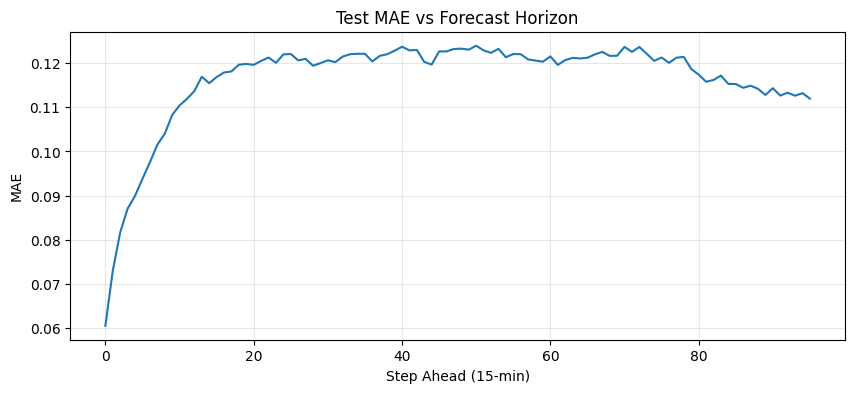

In [44]:
# ---------------------------------------------------------
# 36. Test Error vs Forecast Horizon
# ---------------------------------------------------------

mae_per_step_test = []

for h in range(horizon):
    mae_h = mean_absolute_error(y_test.iloc[:, h], y_test_pred[:, h])
    mae_per_step_test.append(mae_h)

plt.figure(figsize=(10, 4))
plt.plot(mae_per_step_test)

plt.title("Test MAE vs Forecast Horizon")
plt.xlabel("Step Ahead (15-min)")
plt.ylabel("MAE")

plt.grid(alpha=0.3)
plt.show()

In [45]:
# ---------------------------------------------------------
# 37. Save Final Model
# ---------------------------------------------------------

joblib.dump(final_model, "models/load_forecast_model.pkl")

['models/load_forecast_model.pkl']

In [46]:
# ---------------------------------------------------------
# 38. Reload Model
# ---------------------------------------------------------

model = joblib.load("models/load_forecast_model.pkl")

In [47]:
# ---------------------------------------------------------
# 39. Predict Next 24h Load
# ---------------------------------------------------------

def predict_next_24h_load(model, feature_row):
    """
    Predict next 96 steps (24h) given a single feature row
    """
    pred = model.predict(feature_row)
    return pred.flatten()

In [48]:
# ---------------------------------------------------------
# 40. Build Next 24h Forecast Table
# ---------------------------------------------------------

def build_next_24h_load_table(
    model,
    df_house_history,
    weather_at_forecast_time_df,
    feature_cols,
    household_name="residential1"
):
    """
    Build a 24-hour ahead load forecast table using the
    same feature schema as the trained model.
    """

    df_hist = df_house_history.copy()
    df_hist.index = pd.to_datetime(df_hist.index, utc=True)
    df_hist = df_hist.sort_index()

    if "load" not in df_hist.columns:
        raise ValueError("df_house_history must contain 'load' column")

    weather_df_local = weather_at_forecast_time_df.copy()
    weather_df_local["utc_timestamp"] = pd.to_datetime(
        weather_df_local["utc_timestamp"], utc=True
    )
    weather_df_local = weather_df_local.set_index("utc_timestamp").sort_index()

    if len(weather_df_local) != 1:
        raise ValueError("weather_at_forecast_time_df must contain exactly one row")

    forecast_time = weather_df_local.index[0]
    weather_row = weather_df_local.iloc[0].to_dict()
    weather_row.pop("source", None)

    de_holidays = holidays.Germany()

    feature_row = {}

    # calendar features
    if "hour" in feature_cols:
        feature_row["hour"] = forecast_time.hour

    if "day_of_week" in feature_cols:
        feature_row["day_of_week"] = forecast_time.dayofweek

    if "month" in feature_cols:
        feature_row["month"] = forecast_time.month

    if "is_weekend" in feature_cols:
        feature_row["is_weekend"] = int(forecast_time.dayofweek >= 5)

    if "is_holiday" in feature_cols:
        feature_row["is_holiday"] = int(
            forecast_time.tz_localize(None).normalize() in de_holidays
        )

    # lag features
    for col in feature_cols:
        if col.startswith("lag_"):
            lag_val = int(col.split("_")[1])
            if len(df_hist) < lag_val:
                raise ValueError(f"Not enough history for {col}")
            feature_row[col] = df_hist["load"].iloc[-lag_val]

    # rolling features
    if "rolling_mean_1h" in feature_cols:
        if len(df_hist) < 4:
            raise ValueError("Not enough history for rolling_mean_1h")
        feature_row["rolling_mean_1h"] = df_hist["load"].iloc[-4:].mean()

    if "rolling_mean_24h" in feature_cols:
        if len(df_hist) < 96:
            raise ValueError("Not enough history for rolling_mean_24h")
        feature_row["rolling_mean_24h"] = df_hist["load"].iloc[-96:].mean()

    # weather features
    for col in feature_cols:
        if col in weather_row:
            feature_row[col] = weather_row[col]

    missing_cols = [col for col in feature_cols if col not in feature_row]
    if missing_cols:
        raise ValueError(f"Missing required feature columns: {missing_cols}")

    X_latest = pd.DataFrame([feature_row])[feature_cols]

    y_pred = model.predict(X_latest).flatten()

    future_times = pd.date_range(
        start=forecast_time,
        periods=96,
        freq="15min",
        tz="UTC"
    )

    forecast_table = pd.DataFrame({
        "time": future_times,
        "predicted_kwh": np.round(y_pred, 4),
        "predicted_kw": np.round(y_pred * 4, 4),
        "household": household_name,
        "source": "lightgbm_load_forecast"
    })

    return forecast_table

In [49]:
# ---------------------------------------------------------
# 41. Run Example Forecast
# ---------------------------------------------------------

feature_cols = X.columns.tolist()

weather_now_df = weather_df.reset_index().iloc[[-1]].copy()

forecast_table = build_next_24h_load_table(
    model=model,
    df_house_history=df_house[["load"]].copy(),
    weather_at_forecast_time_df=weather_now_df,
    feature_cols=feature_cols,
    household_name=selected_household
)

display(forecast_table.head(12))
print(forecast_table.shape)

,time,predicted_kwh,predicted_kw,household,source
0,2019-05-01 22:00:00+00:00,0.1177,0.4710,residential1,lightgbm_load_forecast
1,2019-05-01 22:15:00+00:00,0.1163,0.4654,residential1,lightgbm_load_forecast
2,2019-05-01 22:30:00+00:00,0.1126,0.4506,residential1,lightgbm_load_forecast
3,2019-05-01 22:45:00+00:00,0.1062,0.4247,residential1,lightgbm_load_forecast
4,2019-05-01 23:00:00+00:00,0.1080,0.4318,residential1,lightgbm_load_forecast
5,2019-05-01 23:15:00+00:00,0.1033,0.4134,residential1,lightgbm_load_forecast
6,2019-05-01 23:30:00+00:00,0.1010,0.4041,residential1,lightgbm_load_forecast
7,2019-05-01 23:45:00+00:00,0.0999,0.3995,residential1,lightgbm_load_forecast
8,2019-05-02 00:00:00+00:00,0.0850,0.3402,residential1,lightgbm_load_forecast
9,2019-05-02 00:15:00+00:00,0.0987,0.3949,residential1,lightgbm_load_forecast


(96, 5)


In [50]:
# ---------------------------------------------------------
# 42. Save Forecast Output
# ---------------------------------------------------------

forecast_output_path = f"data/load_forecast_{selected_household}.csv"

forecast_table.to_csv(forecast_output_path, index=False)

print("Saved forecast to:", forecast_output_path)

Saved forecast to: data/load_forecast_residential1.csv


In [51]:
# ---------------------------------------------------------
# 43. Optional Project-Level Forecast Wrapper Test
# ---------------------------------------------------------

from utils.load_utils import get_daily_load_forecast

load_forecast_table = get_daily_load_forecast(
    target_date="2019-05-01",
    household_id=1
)

display(load_forecast_table.head(12))
print(load_forecast_table.shape)

,time,predicted_kwh,predicted_kw,household,source
0,2019-05-01 00:00:00+00:00,2.1159,8.4636,residential1,weather_aware_load_model
1,2019-05-01 00:15:00+00:00,1.6205,6.4821,residential1,weather_aware_load_model
2,2019-05-01 00:30:00+00:00,1.3080,5.2318,residential1,weather_aware_load_model
3,2019-05-01 00:45:00+00:00,1.2938,5.1754,residential1,weather_aware_load_model
4,2019-05-01 01:00:00+00:00,1.0909,4.3636,residential1,weather_aware_load_model
5,2019-05-01 01:15:00+00:00,1.0084,4.0336,residential1,weather_aware_load_model
6,2019-05-01 01:30:00+00:00,0.7943,3.1773,residential1,weather_aware_load_model
7,2019-05-01 01:45:00+00:00,0.8126,3.2503,residential1,weather_aware_load_model
8,2019-05-01 02:00:00+00:00,0.8708,3.4830,residential1,weather_aware_load_model
9,2019-05-01 02:15:00+00:00,0.7375,2.9501,residential1,weather_aware_load_model


(96, 5)


In [52]:
# ============================================================
# 44. Final Summary
# ============================================================
# This notebook:
# 1. Loaded and prepared household smart meter data
# 2. Built interval-based load series from cumulative readings
# 3. Performed EDA across households
# 4. Selected residential1 for forecasting
# 5. Engineered calendar, lag, rolling, and weather features
# 6. Compared feature sets and selected the full-weather setup
# 7. Trained single-step and multi-step forecasting models
# 8. Tuned and evaluated the final multi-output LightGBM model
# 9. Saved the trained model and generated a 24-hour forecast table
# ============================================================